In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_csv("../data/raw/campaign_data.csv")
df

,campaign_id,campaign_type,platform,region,device,age_group,season,campaign_date,budget,impressions,...,comments,leads,conversions,customer_rating,revenue,spend,profit,roi,bounce_rate,session_duration_sec
0,CMP000000,Search,Facebook,North,Desktop,55+,Summer,2023-07-22,38768.0,362738,...,614,2841,678,5.0,3378062.56,36266.59,3341795.97,9214.53,22.25,292.0
1,CMP000001,Affiliate,Facebook,East,Mobile,35-44,Festive,2025-10-22,20507.0,200613,...,437,2428,822,3.5,9658482.84,18291.93,9640190.91,52701.88,56.03,149.0
2,CMP000002,Search,Google Ads,West,Mobile,55+,Summer,2023-01-11,30433.0,309070,...,835,1890,355,3.9,1422968.99,31975.61,1390993.38,4350.17,45.96,120.0
3,CMP000003,Email,YouTube,West,Desktop,55+,Festive,2024-06-15,46373.0,1188007,...,8222,3499,1199,3.3,11784873.84,38944.35,11745929.49,30160.81,61.83,173.0
4,CMP000004,Influencer,X,West,Desktop,55+,Winter,2025-10-06,65564.0,335654,...,1460,2303,96,5.0,575532.22,64355.34,511176.88,794.30,44.34,57.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50495,CMP000314,Influencer,YouTube,South,Mobile,18-24,Summer,2023-03-07,134674.0,1079924,...,5803,19808,8626,5.0,70638965.85,139338.56,70499627.29,50595.92,31.03,69.0
50496,CMP011449,Influencer,X,East,Mobile,25-34,Festive,2025-12-26,117322.0,3308273,...,4007,30931,7105,4.2,35101807.77,112605.30,34989202.47,31072.43,31.40,203.0
50497,CMP030745,Search,YouTube,North,Desktop,45-54,Festive,2025-02-25,73715.0,2087526,...,10781,18675,6080,4.5,64820194.98,73798.12,64746396.86,87734.48,51.49,113.0
50498,CMP029702,Social Media,Google Ads,West,Desktop,18-24,Festive,2025-01-04,132709.0,2078916,...,4023,10001,2365,4.4,18341755.19,109267.64,18232487.55,16686.08,38.98,354.0


In [3]:
# What is the shape of the dataset?
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 50500
Columns: 23


In [4]:
# What are the data types of all features?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50500 entries, 0 to 50499
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   campaign_id           50500 non-null  object 
 1   campaign_type         50500 non-null  object 
 2   platform              50500 non-null  object 
 3   region                50500 non-null  object 
 4   device                50500 non-null  object 
 5   age_group             50500 non-null  object 
 6   season                50500 non-null  object 
 7   campaign_date         50500 non-null  object 
 8   budget                50500 non-null  float64
 9   impressions           50500 non-null  int64  
 10  clicks                50500 non-null  int64  
 11  likes                 50500 non-null  int64  
 12  shares                50500 non-null  int64  
 13  comments              50500 non-null  int64  
 14  leads                 50500 non-null  int64  
 15  conversions        

In [5]:
# Are there any missing values in the dataset?
df.isnull().sum().sum()

np.int64(7571)

In [6]:
# Are there any duplicate records?
df.duplicated().sum()

np.int64(500)

In [7]:
# How many numerical and categorical features are present?
nums_cols = df.select_dtypes(include="number").columns
len(nums_cols)

cat_cols = df.select_dtypes(include=["object","category"]).columns
len(cat_cols)

8

In [8]:
# What is the date range covered by the campaigns?
df['campaign_date'] = pd.to_datetime(df['campaign_date'],errors='coerce')

print("Earliest Date:", df['campaign_date'].min())
print("Latest Date:", df['campaign_date'].max())

Earliest Date: 2023-01-01 00:00:00
Latest Date: 2025-12-31 00:00:00


# Univariate Analysis

count    5.050000e+04
mean     7.679424e+04
std      6.086031e+04
min      2.878000e+03
25%      3.726425e+04
50%      5.983900e+04
75%      9.686000e+04
max      1.171077e+06
Name: budget, dtype: float64


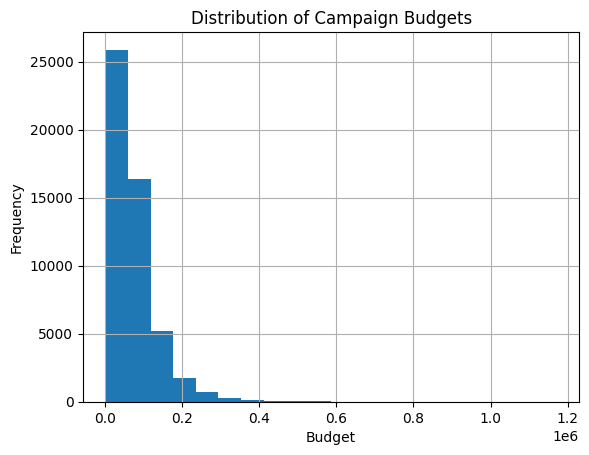

In [9]:
# What is the distribution of campaign budgets?
print(df['budget'].describe())

df['budget'].hist(bins=20)
plt.title('Distribution of Campaign Budgets')
plt.xlabel('Budget')
plt.ylabel('Frequency')
plt.show()

count     50500.000000
mean      12126.588743
std       20478.519402
min         -92.940000
25%        2030.492500
50%        5549.770000
75%       13837.272500
max      651091.710000
Name: roi, dtype: float64


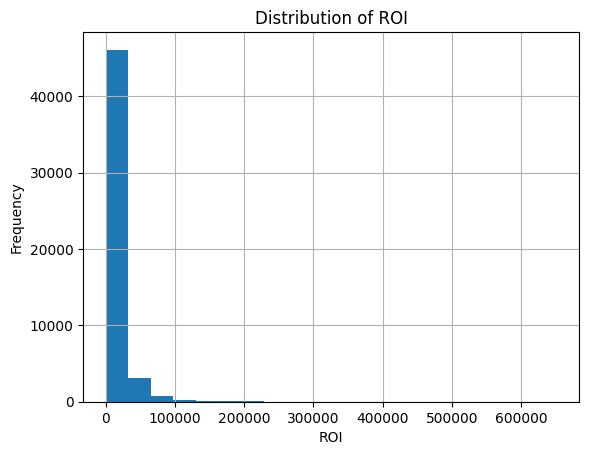

In [10]:
# What is the distribution of ROI?
print(df['roi'].describe())

df['roi'].hist(bins=20)
plt.title('Distribution of ROI')
plt.xlabel('ROI')
plt.ylabel('Frequency')
plt.show()

count    5.050000e+04
mean     8.905089e+06
std      2.082228e+07
min      2.009940e+03
25%      1.076988e+06
50%      3.157966e+06
75%      8.686437e+06
max      1.088069e+09
Name: revenue, dtype: float64


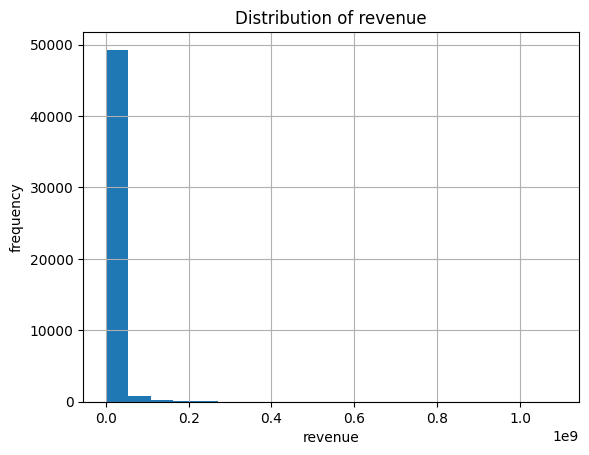

In [11]:
# What is the distribution of revenue?
print(df['revenue'].describe())

df['revenue'].hist(bins=20)
plt.title('Distribution of revenue')
plt.xlabel('revenue')
plt.ylabel('frequency')
plt.show()

In [12]:
# What is the distribution of spend?
df['spend'].describe()

count    5.050000e+04
mean     7.290619e+04
std      5.851099e+04
min      2.818620e+03
25%      3.506997e+04
50%      5.655687e+04
75%      9.201702e+04
max      1.163358e+06
Name: spend, dtype: float64

In [13]:
# What is the distribution of profit?
df['profit'].describe()

count    5.050000e+04
mean     8.832182e+06
std      2.080168e+07
min     -1.685446e+05
25%      1.020961e+06
50%      3.091575e+06
75%      8.604704e+06
max      1.087883e+09
Name: profit, dtype: float64

In [14]:
# What is the distribution of impressions?
df['impressions'].describe()

count    5.050000e+04
mean     1.007022e+06
std      9.803039e+05
min      2.809100e+04
25%      4.074005e+05
50%      7.164700e+05
75%      1.258207e+06
max      2.782833e+07
Name: impressions, dtype: float64

In [15]:
# What is the distribution of clicks?
df['clicks'].describe()

count     50500.000000
mean      28281.249881
std       30994.679733
min         105.000000
25%       10019.000000
50%       18879.000000
75%       35264.500000
max      763659.000000
Name: clicks, dtype: float64

In [16]:
# What is the distribution of leads?
df['leads'].describe()

count     50500.000000
mean       5212.994931
std        7010.950152
min          14.000000
25%        1385.000000
50%        3014.500000
75%        6292.000000
max      249045.000000
Name: leads, dtype: float64

In [17]:
# What is the distribution of conversions?
df['conversions'].describe()

count    50500.000000
mean      1214.495921
std       1985.603192
min          1.000000
25%        241.000000
50%        589.000000
75%       1386.000000
max      55831.000000
Name: conversions, dtype: float64

In [18]:
# Which campaign type occurs most frequently?
df['campaign_type'].value_counts(normalize=True) * 100

campaign_type
Search          20.378218
Influencer      20.291089
Email           19.920792
Social Media    19.718812
Affiliate       19.691089
Name: proportion, dtype: float64

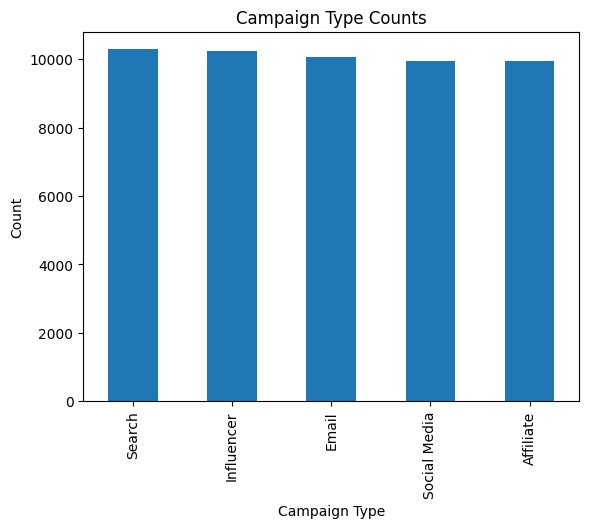

In [19]:
df['campaign_type'].value_counts().plot(kind='bar')
plt.title('Campaign Type Counts')
plt.xlabel('Campaign Type')
plt.ylabel('Count')
plt.show()

In [20]:
# Which platform is used most often?
df['platform'].value_counts()

platform
Google Ads    8576
YouTube       8477
X             8438
LinkedIn      8370
Facebook      8320
Instagram     8319
Name: count, dtype: int64

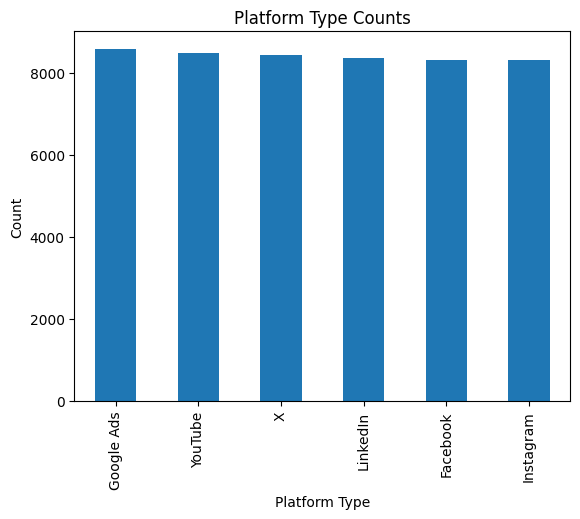

In [21]:
df['platform'].value_counts().plot(kind='bar')
plt.title('Platform Type Counts')
plt.xlabel('Platform Type')
plt.ylabel('Count')
plt.show()

In [22]:
# Which region has the highest number of campaigns?
df['region'].value_counts()

region
North      10253
South      10152
East       10140
West        9987
Central     9968
Name: count, dtype: int64

In [23]:
# Which device type dominates the dataset?
df['device'].value_counts()

device
Tablet     16880
Desktop    16863
Mobile     16757
Name: count, dtype: int64

In [24]:
# Which season has the highest number of campaigns?
df['season'].value_counts()

season
Winter     12741
Festive    12694
Summer     12612
Monsoon    12453
Name: count, dtype: int64

In [25]:
# What is the distribution of customer ratings?
df['customer_rating'].describe()

count    47975.000000
mean         3.988411
std          0.576290
min          1.500000
25%          3.600000
50%          4.000000
75%          4.400000
max          5.000000
Name: customer_rating, dtype: float64

In [26]:
# What is the distribution of bounce rates?
df['bounce_rate'].describe()

count    47977.000000
mean        50.035539
std         17.383122
min         20.000000
25%         34.900000
50%         50.040000
75%         65.190000
max         80.000000
Name: bounce_rate, dtype: float64

In [27]:
# What is the distribution of session duration?
df['session_duration_sec'].describe()

count    47977.000000
mean       180.125289
std        103.466987
min          3.000000
25%        104.000000
50%        161.000000
75%        235.000000
max        929.000000
Name: session_duration_sec, dtype: float64

In [28]:
# Which season has the highest number of campaigns?
df['season'].value_counts()

season
Winter     12741
Festive    12694
Summer     12612
Monsoon    12453
Name: count, dtype: int64

In [29]:
# Which age group is targeted most frequently?
df['age_group'].value_counts()

age_group
55+      10189
45-54    10155
25-34    10148
35-44    10047
18-24     9961
Name: count, dtype: int64

# Outlier Analysis

In [30]:
# Are there outliers in budget?
z_scores = np.abs(stats.zscore(df['budget']))
outliers = df[z_scores > 3]
print("Number of outliers:", len(outliers))
print(outliers)

Number of outliers: 947
      campaign_id campaign_type    platform   region   device age_group  \
70      CMP000070     Affiliate   Instagram     West   Tablet     35-44   
89      CMP000089         Email   Instagram    North   Tablet     45-54   
115     CMP000115    Influencer    Facebook    North  Desktop     25-34   
132     CMP000132        Search   Instagram     West  Desktop     45-54   
162     CMP000162  Social Media  Google Ads  Central  Desktop     35-44   
...           ...           ...         ...      ...      ...       ...   
50363   CMP019245        Search  Google Ads     West  Desktop     25-34   
50394   CMP026158     Affiliate   Instagram     West   Tablet     25-34   
50439   CMP001118         Email  Google Ads    North  Desktop       55+   
50442   CMP032684        Search   Instagram     East  Desktop     25-34   
50469   CMP049184         Email    Facebook     East  Desktop     18-24   

        season campaign_date    budget  impressions  ...  comments  leads  

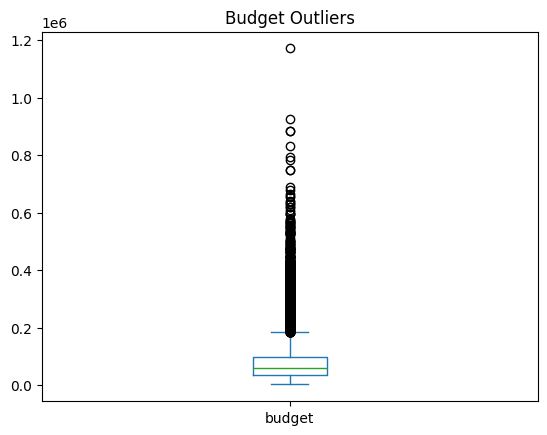

In [31]:
df['budget'].plot(kind='box')
plt.title('Budget Outliers')
plt.show()

In [32]:
# Are there outliers in revenue?
z_scores = np.abs(stats.zscore(df['revenue']))
outliers = df[z_scores > 3]
print("Number of outliers:", len(outliers))
print(outliers)

Number of outliers: 788
      campaign_id campaign_type    platform   region   device age_group  \
70      CMP000070     Affiliate   Instagram     West   Tablet     35-44   
131     CMP000131  Social Media     YouTube  Central   Tablet     18-24   
144     CMP000144         Email     YouTube     West   Mobile     35-44   
172     CMP000172    Influencer  Google Ads    South   Mobile       55+   
248     CMP000248        Search    Facebook  Central   Tablet     18-24   
...           ...           ...         ...      ...      ...       ...   
50353   CMP046358        Search     YouTube     East   Mobile     35-44   
50363   CMP019245        Search  Google Ads     West  Desktop     25-34   
50426   CMP016399     Affiliate    LinkedIn     West   Mobile     25-34   
50439   CMP001118         Email  Google Ads    North  Desktop       55+   
50467   CMP047767         Email    Facebook  Central  Desktop     35-44   

        season campaign_date    budget  impressions  ...  comments  leads  

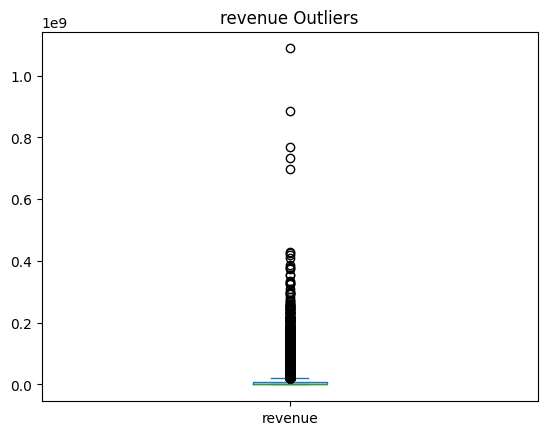

In [33]:
df['revenue'].plot(kind='box')
plt.title('revenue Outliers')
plt.show()

In [34]:
# Are there outliers in profit?
z_scores = np.abs(stats.zscore(df['profit']))
outliers = df[z_scores > 3]
print("Number of outliers:", len(outliers))
print(outliers)

Number of outliers: 787
      campaign_id campaign_type    platform   region   device age_group  \
70      CMP000070     Affiliate   Instagram     West   Tablet     35-44   
131     CMP000131  Social Media     YouTube  Central   Tablet     18-24   
144     CMP000144         Email     YouTube     West   Mobile     35-44   
172     CMP000172    Influencer  Google Ads    South   Mobile       55+   
248     CMP000248        Search    Facebook  Central   Tablet     18-24   
...           ...           ...         ...      ...      ...       ...   
50353   CMP046358        Search     YouTube     East   Mobile     35-44   
50363   CMP019245        Search  Google Ads     West  Desktop     25-34   
50426   CMP016399     Affiliate    LinkedIn     West   Mobile     25-34   
50439   CMP001118         Email  Google Ads    North  Desktop       55+   
50467   CMP047767         Email    Facebook  Central  Desktop     35-44   

        season campaign_date    budget  impressions  ...  comments  leads  

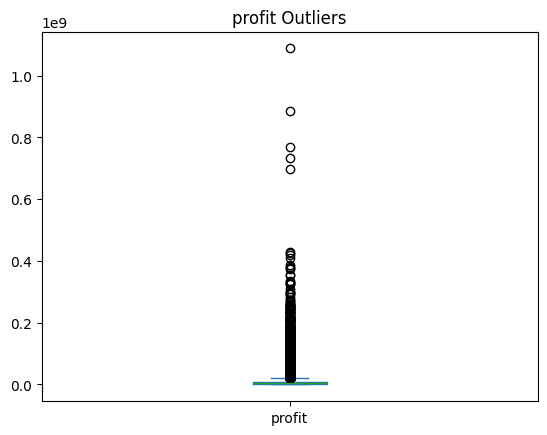

In [35]:
df['profit'].plot(kind='box')
plt.title('profit Outliers')
plt.show()

In [36]:
# Are there outliers in profit?
z_scores = np.abs(stats.zscore(df['roi']))
outliers = df[z_scores > 3]
print("Number of outliers:", len(outliers))
print(outliers)

Number of outliers: 933
      campaign_id campaign_type    platform   region   device age_group  \
62      CMP000062     Affiliate  Google Ads     West   Tablet       55+   
87      CMP000087         Email     YouTube     West  Desktop     45-54   
101     CMP000101  Social Media  Google Ads  Central   Tablet     25-34   
107     CMP000107    Influencer  Google Ads     East   Tablet       55+   
110     CMP000110         Email  Google Ads     West   Tablet     35-44   
...           ...           ...         ...      ...      ...       ...   
50196   CMP026178    Influencer   Instagram    North   Mobile     18-24   
50228   CMP003732    Influencer    LinkedIn     East   Mobile       55+   
50236   CMP012007    Influencer  Google Ads    North  Desktop     35-44   
50353   CMP046358        Search     YouTube     East   Mobile     35-44   
50497   CMP030745        Search     YouTube    North  Desktop     45-54   

        season campaign_date    budget  impressions  ...  comments  leads  

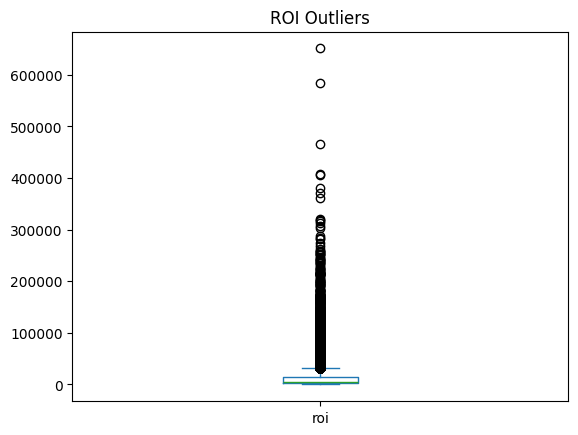

In [37]:
df['roi'].plot(kind='box')
plt.title('ROI Outliers')
plt.show()

In [38]:
# Which campaigns have exceptionally high or low conversion counts?

Q1 = df['conversions'].quantile(0.25)
Q3 = df['conversions'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


def conversion_category(conversions):
    if conversions > upper_bound:
        return "High Conversion Outlier"
    elif conversions < lower_bound:
        return "Low Conversion Outlier"
    else:
        return "Normal"


df['conversion_category'] = df['conversions'].apply(conversion_category)

df[['conversions', 'conversion_category']].head()

,conversions,conversion_category
0,678,Normal
1,822,Normal
2,355,Normal
3,1199,Normal
4,96,Normal


In [51]:
# Which campaigns have unusually high bounce rates?
Q1 = df['bounce_rate'].quantile(0.25)
Q3 = df['bounce_rate'].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

def bounce_rate_status(rate, upper_bound):
    if rate > upper_bound:
        return "Unusually High Bounce Rate"
    else:
        return "Normal Bounce Rate"

df['bounce_rate_status'] = df['bounce_rate'].apply(
    lambda x: bounce_rate_status(x, upper_bound)
)

df[['campaign_id', 'bounce_rate', 'bounce_rate_status']]

,campaign_id,bounce_rate,bounce_rate_status
0,CMP000000,22.25,Normal Bounce Rate
1,CMP000001,56.03,Normal Bounce Rate
2,CMP000002,45.96,Normal Bounce Rate
3,CMP000003,61.83,Normal Bounce Rate
4,CMP000004,44.34,Normal Bounce Rate
...,...,...,...
50495,CMP000314,31.03,Normal Bounce Rate
50496,CMP011449,31.40,Normal Bounce Rate
50497,CMP030745,51.49,Normal Bounce Rate
50498,CMP029702,38.98,Normal Bounce Rate


# Campaign Performance Analysis

In [55]:
# Which campaign type generates the highest average ROI?
df.groupby('campaign_type')['roi'].mean().sort_values(ascending=False)

campaign_type
Search          12276.834288
Social Media    12274.399163
Influencer      12193.073545
Email           12007.528712
Affiliate       11875.020064
Name: roi, dtype: float64

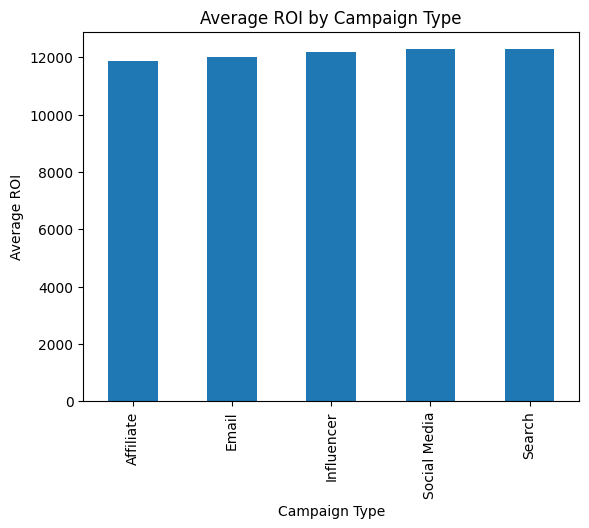

In [56]:
df.groupby('campaign_type')['roi'].mean().sort_values().plot(kind='bar')

plt.title('Average ROI by Campaign Type')
plt.xlabel('Campaign Type')
plt.ylabel('Average ROI')
plt.show()

In [57]:
# Which campaign type generates the highest revenue?
df.groupby('campaign_type')['revenue'].mean().sort_values(ascending=False)

campaign_type
Search          9.084814e+06
Affiliate       8.938796e+06
Influencer      8.916662e+06
Email           8.800997e+06
Social Media    8.778941e+06
Name: revenue, dtype: float64

In [60]:
# Which campaign type generates the highest conversion rate?
df.groupby('campaign_type')['conversions'].mean().sort_values(ascending=False)

campaign_type
Search          1236.295598
Affiliate       1214.067679
Influencer      1210.660486
Email           1207.897416
Social Media    1203.007732
Name: conversions, dtype: float64

# Platform Analysis

In [62]:
# Which platform generates the highest ROI?
df.groupby('platform')['roi'].mean().sort_values(ascending=False)

platform
Google Ads    18428.569862
YouTube       16014.591727
Instagram     13276.435378
Facebook      11502.764013
LinkedIn       7464.605459
X              5921.452016
Name: roi, dtype: float64

In [64]:
df['conversion_rate'] = (
    df['conversions'] / df['clicks']
) * 100

In [65]:
# Which platform generates the highest conversion rate?
df.groupby('platform')['conversion_rate'].mean().sort_values(ascending=False)

platform
Google Ads    6.487815
YouTube       5.599903
Instagram     4.733946
Facebook      4.047265
LinkedIn      2.631095
X             2.113752
Name: conversion_rate, dtype: float64

# Customer & Regional Analysis

In [67]:
# Which age group generates the highest ROI?
df.groupby('age_group')['roi'].mean().sort_values(ascending=False)

age_group
25-34    12468.923495
18-24    12152.059296
55+      12101.447846
45-54    12035.641504
35-44    11872.981155
Name: roi, dtype: float64

In [68]:
# Which region generates the highest revenue?
df.groupby('region')['revenue'].mean().sort_values(ascending=False)

region
West       9.202058e+06
South      9.074079e+06
North      8.873742e+06
East       8.739189e+06
Central    8.636449e+06
Name: revenue, dtype: float64

# Correlation Analysis

In [69]:
# Which variables are most strongly correlated with ROI?
df.corr(numeric_only=True)['roi'].sort_values(ascending=False)

roi                     1.000000
profit                  0.728009
revenue                 0.727287
conversions             0.515737
conversion_rate         0.478509
leads                   0.406390
clicks                  0.249457
likes                   0.222625
comments                0.201608
shares                  0.201124
impressions             0.176352
budget                  0.005373
session_duration_sec    0.003842
customer_rating         0.003275
spend                  -0.000739
bounce_rate            -0.010609
Name: roi, dtype: float64

In [70]:
# Is budget strongly correlated with revenue?
df[['budget', 'revenue']].corr()

,budget,revenue
budget,1.000000,0.355747
revenue,0.355747,1.000000


In [73]:
# Is bounce rate negatively correlated with conversions?
df[['bounce_rate', 'conversions']].corr()

,bounce_rate,conversions
bounce_rate,1.000000,-0.004535
conversions,-0.004535,1.000000


In [75]:
# What factors contribute most to campaign success?
(
    df.corr(numeric_only=True)['roi']
      .drop('roi')
      .sort_values(key=abs, ascending=False)
)

profit                  0.728009
revenue                 0.727287
conversions             0.515737
conversion_rate         0.478509
leads                   0.406390
clicks                  0.249457
likes                   0.222625
comments                0.201608
shares                  0.201124
impressions             0.176352
bounce_rate            -0.010609
budget                  0.005373
session_duration_sec    0.003842
customer_rating         0.003275
spend                  -0.000739
Name: roi, dtype: float64

In [61]:
df.columns

Index(['campaign_id', 'campaign_type', 'platform', 'region', 'device',
       'age_group', 'season', 'campaign_date', 'budget', 'impressions',
       'clicks', 'likes', 'shares', 'comments', 'leads', 'conversions',
       'customer_rating', 'revenue', 'spend', 'profit', 'roi', 'bounce_rate',
       'session_duration_sec', 'conversion_category', 'bounce_rate_category',
       'bounce_rate_status'],
      dtype='object')